In [ ]:
# Vérification de CUDA et PyTorch
import torch
import sys

print("=== VÉRIFICATION DE L'ENVIRONNEMENT CUDA/PYTORCH ===")
print(f"Version Python: {sys.version}")
print(f"Version PyTorch: {torch.__version__}")

# Vérification de CUDA
print(f"\nCUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Nombre de GPU(s): {torch.cuda.device_count()}")
    print(f"GPU actuel: {torch.cuda.current_device()}")
    print(f"Nom du GPU: {torch.cuda.get_device_name(0)}")
    print(f"Version CUDA (PyTorch): {torch.version.cuda}")
    print(f"Mémoire GPU totale: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
    print(f"Mémoire GPU allouée: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")
    print(f"Mémoire GPU libre: {torch.cuda.memory_reserved(0) / 1024**3:.2f} GB")
    
    # Test simple pour vérifier que CUDA fonctionne
    print("\n=== TEST CUDA ===")
    device = torch.device("cuda:0")
    x = torch.randn(3, 3).to(device)
    y = torch.randn(3, 3).to(device)
    z = torch.matmul(x, y)
    print(f"Test de multiplication matricielle sur GPU: {'✓ SUCCÈS' if z.is_cuda else '✗ ÉCHEC'}")
    print(f"Résultat sur device: {z.device}")
else:
    print("CUDA n'est pas disponible. Vérifiez l'installation de PyTorch avec support CUDA.")

print("\n" + "="*60)

SyntaxError: unterminated string literal (detected at line 21) (1128156371.py, line 21)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import librosa
import IPython.display as ipd
from collections import defaultdict

# Configuration pour les graphiques
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (15, 8)

In [ ]:
from datasets import load_dataset
ds = load_dataset("diarizers-community/voxconverse")

print(ds)


DatasetDict({
    dev: Dataset({
        features: ['audio', 'timestamps_start', 'timestamps_end', 'speakers'],
        num_rows: 216
    })
    test: Dataset({
        features: ['audio', 'timestamps_start', 'timestamps_end', 'speakers'],
        num_rows: 232
    })
})


In [ ]:
# Explorer la structure du dataset VoxConverse
print("=== STRUCTURE DU DATASET VOXCONVERSE ===")
print(f"Splits disponibles: {list(ds.keys())}")
print(f"Nombre d'éléments dans dev: {len(ds['dev'])}")
print(f"Nombre d'éléments dans test: {len(ds['test'])}")

print("\n=== FEATURES DISPONIBLES ===")
print("Features:", ds['dev'].features)

print("\n=== PREMIER ÉLÉMENT DU DATASET (DEV) ===")
first_item = ds['dev'][0]
for key, value in first_item.items():
    if key == 'audio':
        print(f"{key}: array de shape {np.array(value['array']).shape}, sample_rate={value['sampling_rate']}")
    elif key == 'timestamps_start':
        print(f"{key}: {len(value)} timestamps de début - premiers: {value[:5] if len(value) > 5 else value}")
    elif key == 'timestamps_end':
        print(f"{key}: {len(value)} timestamps de fin - premiers: {value[:5] if len(value) > 5 else value}")
    elif key == 'speakers':
        print(f"{key}: {len(value)} labels de locuteurs - premiers: {value[:10] if len(value) > 10 else value}")
        unique_speakers = list(set(value))
        print(f"  Locuteurs uniques: {unique_speakers}")
        print(f"  Nombre de locuteurs uniques: {len(unique_speakers)}")
    elif isinstance(value, str):
        print(f"{key}: {value}")
    else:
        print(f"{key}: {value}")

# Analyser la structure des timestamps et speakers
if 'timestamps_start' in first_item and 'timestamps_end' in first_item and 'speakers' in first_item:
    timestamps_start = first_item['timestamps_start']
    timestamps_end = first_item['timestamps_end']
    speakers = first_item['speakers']
    
    print(f"\n=== ANALYSE DES SEGMENTS DE DIARIZATION ===")
    print(f"Nombre de segments: {len(timestamps_start)}")
    
    if len(timestamps_start) > 0:
        print(f"Premiers segments:")
        for i in range(min(5, len(timestamps_start))):
            duration = timestamps_end[i] - timestamps_start[i]
            print(f"  Segment {i+1}: {timestamps_start[i]:.2f}s-{timestamps_end[i]:.2f}s ({duration:.2f}s), Locuteur: {speakers[i]}")

print(f"\nDurée audio: {len(first_item['audio']['array']) / first_item['audio']['sampling_rate']:.2f} secondes")

=== STRUCTURE DU DATASET VOXCONVERSE ===
Splits disponibles: ['dev', 'test']
Nombre d'éléments dans dev: 216
Nombre d'éléments dans test: 232

=== FEATURES DISPONIBLES ===
Features: {'audio': Audio(sampling_rate=None, decode=True, stream_index=None), 'timestamps_start': List(Value('float64')), 'timestamps_end': List(Value('float64')), 'speakers': List(Value('string'))}

=== PREMIER ÉLÉMENT DU DATASET (DEV) ===
audio: array de shape (2860513,), sample_rate=16000
timestamps_start: 23 timestamps de début - premiers: [34.72, 178.12, 65.56, 98.04, 113.84]
timestamps_end: 23 timestamps de fin - premiers: [42.36, 178.76, 96.24000000000001, 98.76, 115.0]
speakers: 23 labels de locuteurs - premiers: ['spk00', 'spk01', 'spk02', 'spk02', 'spk02', 'spk02', 'spk02', 'spk02', 'spk02', 'spk03']
  Locuteurs uniques: ['spk01', 'spk03', 'spk00', 'spk02']
  Nombre de locuteurs uniques: 4

=== ANALYSE DES SEGMENTS DE DIARIZATION ===
Nombre de segments: 23
Premiers segments:
  Segment 1: 34.72s-42.36s (7.6

In [ ]:
def analyze_voxconverse_item(item):
    """
    Analyse un élément du dataset VoxConverse et extrait les informations de diarization
    """
    # Créer les segments à partir des timestamps
    segments = []
    timestamps_start = item['timestamps_start']
    timestamps_end = item['timestamps_end'] 
    speakers = item['speakers']
    
    for i in range(len(timestamps_start)):
        segment_info = {
            'start': timestamps_start[i],
            'end': timestamps_end[i],
            'speaker': speakers[i]
        }
        segments.append(segment_info)
    
    # Trier par temps de début
    segments.sort(key=lambda x: x['start'])
    
    item_info = {
        'audio_id': f"voxconverse_item",  # VoxConverse n'a pas d'audio_id explicite
        'audio': item['audio'],
        'segments': segments
    }
    
    return item_info

def plot_voxconverse_timeline(item_info, max_time=None, title_suffix=""):
    """
    Trace la timeline des segments de locuteurs pour un élément VoxConverse
    """
    segments = item_info['segments']
    audio_id = item_info['audio_id']
    
    if not segments:
        print(f"Aucun segment trouvé pour {audio_id}")
        return []
    
    # Déterminer la durée maximale
    if max_time is None:
        max_time = max([seg['end'] for seg in segments]) if segments else 60
    
    fig, ax = plt.subplots(1, 1, figsize=(15, 6))
    
    # Timeline des locuteurs
    speakers = list(set(seg['speaker'] for seg in segments))
    speaker_colors = plt.cm.Set3(np.linspace(0, 1, len(speakers)))
    speaker_color_map = dict(zip(speakers, speaker_colors))
    
    segments_in_range = []
    
    for i, segment in enumerate(segments):
        start_time = segment['start']
        end_time = min(segment['end'], max_time)
        speaker = segment['speaker']
        
        if start_time < max_time:  # Seulement si le segment commence dans la période d'intérêt
            segments_in_range.append(segment)
            
            # Tracer le segment
            ax.barh(speaker, end_time - start_time, left=start_time, 
                    color=speaker_color_map[speaker], alpha=0.7, 
                    edgecolor='black', linewidth=0.5)
            
            # Ajouter le numéro du segment si assez long
            if end_time - start_time > 2:  
                ax.text(start_time + (end_time - start_time)/2, speaker, 
                        f"{i+1}", ha='center', va='center', fontsize=8, fontweight='bold')
    
    ax.set_xlabel('Temps (secondes)')
    ax.set_ylabel('Locuteur')
    ax.set_title(f'Timeline des locuteurs - VoxConverse{title_suffix}')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, max_time)
    
    plt.tight_layout()
    plt.show()
    
    # Afficher les statistiques
    print(f"\n=== STATISTIQUES ===")
    print(f"Période analysée: 0-{max_time}s")
    print(f"Nombre de segments dans cette période: {len(segments_in_range)}")
    print(f"Nombre total de segments: {len(segments)}")
    print(f"Nombre de locuteurs: {len(speakers)}")
    print(f"Locuteurs: {speakers}")
    
    if segments_in_range:
        durations = [min(s['end'], max_time) - s['start'] for s in segments_in_range if s['start'] < max_time]
        print(f"Durée moyenne des segments: {np.mean(durations):.2f} secondes")
        
        # Temps de parole par locuteur
        speaker_time = {}
        for seg in segments_in_range:
            speaker = seg['speaker']
            duration = min(seg['end'], max_time) - seg['start']
            if duration > 0:
                speaker_time[speaker] = speaker_time.get(speaker, 0) + duration
        
        print(f"\nTemps de parole par locuteur:")
        for speaker, time in sorted(speaker_time.items()):
            percentage = (time / max_time) * 100
            print(f"  {speaker}: {time:.2f}s ({percentage:.1f}%)")
    
    return segments_in_range

def get_voxconverse_audio_extract(item, start_time=0, duration=60):
    """
    Extrait une portion d'audio d'un élément VoxConverse
    """
    audio_array = np.array(item['audio']['array'])
    sample_rate = item['audio']['sampling_rate']
    
    # Calculer les indices d'échantillons
    start_sample = int(start_time * sample_rate)
    end_sample = int((start_time + duration) * sample_rate)
    
    # S'assurer de ne pas dépasser la longueur de l'audio
    start_sample = min(start_sample, len(audio_array))
    end_sample = min(end_sample, len(audio_array))
    
    # Extraire la portion d'audio
    if start_sample < len(audio_array):
        extracted_audio = audio_array[start_sample:end_sample]
        actual_duration = len(extracted_audio) / sample_rate
    else:
        extracted_audio = np.array([])
        actual_duration = 0
    
    total_duration = len(audio_array) / sample_rate
    
    print(f"Audio extrait: {actual_duration:.2f} secondes (de {start_time:.2f}s à {start_time + actual_duration:.2f}s)")
    print(f"Durée totale de l'audio: {total_duration:.2f} secondes")
    
    return extracted_audio, sample_rate

In [ ]:
# Explorer les premiers éléments du dataset VoxConverse
print("=== EXPLORATION DES ÉLÉMENTS VOXCONVERSE ===")

# Utiliser le split 'dev' puisqu'il n'y a pas de 'train'
split_to_use = 'dev'
dataset_split = ds[split_to_use]

# Analyser les premiers éléments
num_items_to_explore = min(3, len(dataset_split))
print(f"Exploration des {num_items_to_explore} premiers éléments du split '{split_to_use}'")

for i in range(num_items_to_explore):
    item = dataset_split[i]
    
    print(f"\n{'='*60}")
    print(f"ÉLÉMENT {i+1}/{num_items_to_explore}")
    print(f"{'='*60}")
    
    
    # Analyser l'élément
    item_info = analyze_voxconverse_item(item)
    
    print(f"Durée audio totale: {len(item['audio']['array']) / item['audio']['sampling_rate']:.2f} secondes")
    print(f"Sample rate: {item['audio']['sampling_rate']} Hz")
    print(f"Nombre de segments: {len(item_info['segments'])}")
    
    if item_info['segments']:
        # Afficher les speakers uniques
        unique_speakers = list(set(seg['speaker'] for seg in item_info['segments']))
        print(f"Locuteurs uniques: {unique_speakers} ({len(unique_speakers)} locuteurs)")
        
        # Afficher les premiers segments
        print(f"\nPremiers segments:")
        for j, seg in enumerate(item_info['segments'][:8]):  # Afficher jusqu'à 8 segments
            duration = seg['end'] - seg['start']
            print(f"  Segment {j+1}: {seg['start']:.2f}s-{seg['end']:.2f}s ({duration:.2f}s), Locuteur: {seg['speaker']}")
        
        if len(item_info['segments']) > 8:
            print(f"  ... et {len(item_info['segments']) - 8} autres segments")
            
        # Calculer les statistiques de base
        durations = [seg['end'] - seg['start'] for seg in item_info['segments']]
        total_speech_time = sum(durations)
        total_audio_time = len(item['audio']['array']) / item['audio']['sampling_rate']
        coverage = (total_speech_time / total_audio_time) * 100
        
        print(f"\nStatistiques:")
        print(f"  Temps total de parole: {total_speech_time:.2f}s")
        print(f"  Couverture de l'audio: {coverage:.1f}%")
        print(f"  Durée moyenne des segments: {np.mean(durations):.2f}s")
    
    print(f"\n" + "-"*60)

=== EXPLORATION DES ÉLÉMENTS VOXCONVERSE ===
Exploration des 3 premiers éléments du split 'dev'

ÉLÉMENT 1/3
Durée audio totale: 178.78 secondes
Sample rate: 16000 Hz
Nombre de segments: 23
Locuteurs uniques: ['spk03', 'spk01', 'spk00', 'spk02'] (4 locuteurs)

Premiers segments:
  Segment 1: 0.16s-34.00s (33.84s), Locuteur: spk03
  Segment 2: 34.72s-42.36s (7.64s), Locuteur: spk00
  Segment 3: 42.40s-66.20s (23.80s), Locuteur: spk03
  Segment 4: 65.56s-96.24s (30.68s), Locuteur: spk02
  Segment 5: 68.28s-68.92s (0.64s), Locuteur: spk03
  Segment 6: 80.72s-81.24s (0.52s), Locuteur: spk00
  Segment 7: 96.24s-100.20s (3.96s), Locuteur: spk00
  Segment 8: 98.04s-98.76s (0.72s), Locuteur: spk02
  ... et 15 autres segments

Statistiques:
  Temps total de parole: 183.00s
  Couverture de l'audio: 102.4%
  Durée moyenne des segments: 7.96s

------------------------------------------------------------

ÉLÉMENT 2/3
Durée audio totale: 198.36 secondes
Sample rate: 16000 Hz
Nombre de segments: 17
L

=== ANALYSE DÉTAILLÉE DU PREMIER ÉLÉMENT VOXCONVERSE ===
Durée totale: 178.78 secondes
Nombre de segments: 23

=== TIMELINE DES LOCUTEURS (2 premières minutes) ===
Durée totale: 178.78 secondes
Nombre de segments: 23

=== TIMELINE DES LOCUTEURS (2 premières minutes) ===


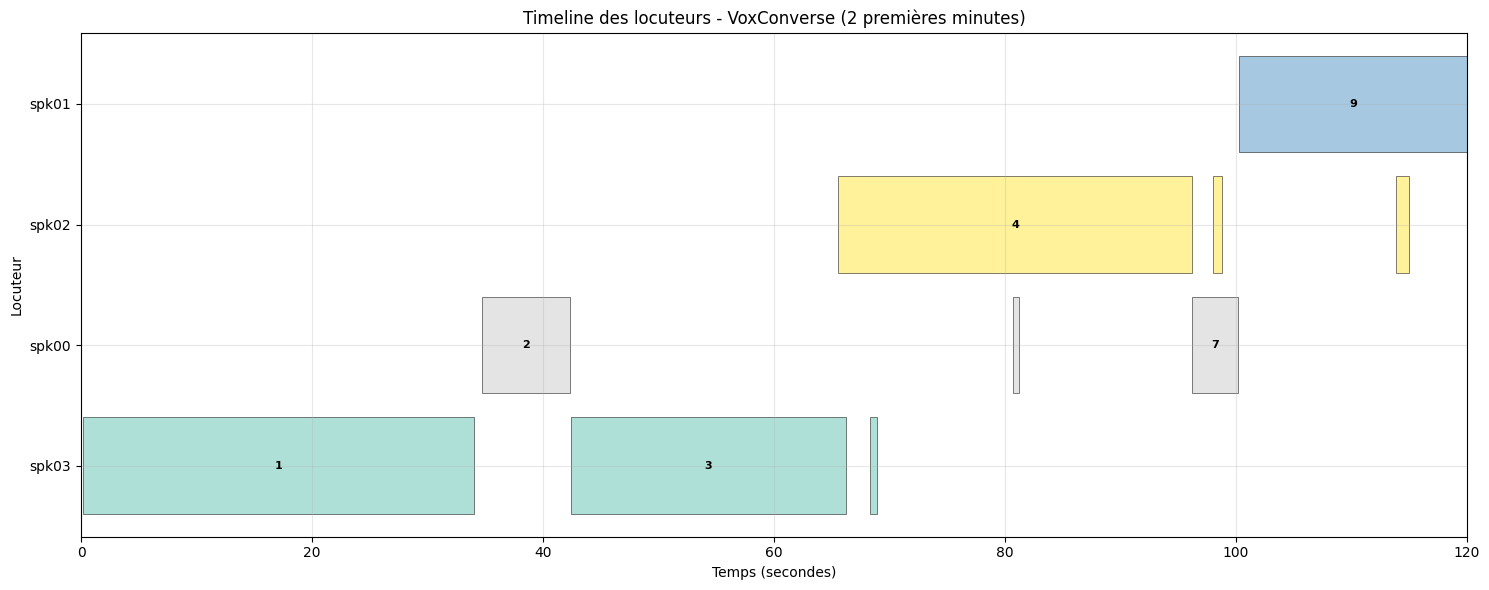


=== STATISTIQUES ===
Période analysée: 0-120s
Nombre de segments dans cette période: 10
Nombre total de segments: 23
Nombre de locuteurs: 4
Locuteurs: ['spk03', 'spk01', 'spk00', 'spk02']
Durée moyenne des segments: 12.27 secondes

Temps de parole par locuteur:
  spk00: 12.12s (10.1%)
  spk01: 19.72s (16.4%)
  spk02: 32.56s (27.1%)
  spk03: 58.28s (48.6%)

=== DÉTAIL DES SEGMENTS (2 premières minutes) ===
Segment 1: 0.16s-34.00s (33.84s), Locuteur: spk03
Segment 2: 34.72s-42.36s (7.64s), Locuteur: spk00
Segment 3: 42.40s-66.20s (23.80s), Locuteur: spk03
Segment 4: 65.56s-96.24s (30.68s), Locuteur: spk02
Segment 5: 68.28s-68.92s (0.64s), Locuteur: spk03
Segment 6: 80.72s-81.24s (0.52s), Locuteur: spk00
Segment 7: 96.24s-100.20s (3.96s), Locuteur: spk00
Segment 8: 98.04s-98.76s (0.72s), Locuteur: spk02
Segment 9: 100.28s-123.24s (19.72s), Locuteur: spk01
Segment 10: 113.84s-115.00s (1.16s), Locuteur: spk02

=== AUDIO DES 2 PREMIÈRES MINUTES ===
Audio extrait: 120.00 secondes (de 0.00s à

In [ ]:
# Analyse détaillée du premier élément VoxConverse avec timeline et audio
print("=== ANALYSE DÉTAILLÉE DU PREMIER ÉLÉMENT VOXCONVERSE ===")

if len(ds['dev']) > 0:
    first_item = ds['dev'][0]
    
    # Analyser l'élément
    item_info = analyze_voxconverse_item(first_item)
    
    total_duration = len(first_item['audio']['array']) / first_item['audio']['sampling_rate']
    print(f"Durée totale: {total_duration:.2f} secondes")
    print(f"Nombre de segments: {len(item_info['segments'])}")
    
    # Tracer la timeline pour les 2 premières minutes
    if item_info['segments']:
        print(f"\n=== TIMELINE DES LOCUTEURS (2 premières minutes) ===")
        segments_120s = plot_voxconverse_timeline(item_info, max_time=120, title_suffix=" (2 premières minutes)")
        
        # Afficher les détails des segments dans les 2 premières minutes
        print(f"\n=== DÉTAIL DES SEGMENTS (2 premières minutes) ===")
        for j, seg in enumerate(segments_120s[:12]):  # Limiter à 12 segments
            duration = min(seg['end'], 120) - seg['start']
            print(f"Segment {j+1}: {seg['start']:.2f}s-{seg['end']:.2f}s ({duration:.2f}s), "
                  f"Locuteur: {seg['speaker']}")
        
        if len(segments_120s) > 12:
            print(f"... et {len(segments_120s) - 12} autres segments")
        
        # Extraire et jouer l'audio des 2 premières minutes (120 secondes)
        print(f"\n=== AUDIO DES 2 PREMIÈRES MINUTES ===")
        two_minutes_audio, sr = get_voxconverse_audio_extract(first_item, start_time=0, duration=120)
        
        if len(two_minutes_audio) > 0:
            print(f"Sample rate: {sr} Hz")
            print(f"Lecteur audio des 2 premières minutes:")
            display(ipd.Audio(two_minutes_audio, rate=sr))
        else:
            print("Aucun audio disponible pour les 2 premières minutes")
    else:
        print("Aucun segment de diarization trouvé")
else:
    print("Dataset vide")

=== DISTRIBUTION DU TEMPS DES CONVERSATIONS - VOXCONVERSE ===
Analyse du split 'dev'...
  Traitement élément 1/216
  Traitement élément 1/216
  Traitement élément 51/216
  Traitement élément 51/216
  Traitement élément 101/216
  Traitement élément 101/216
  Traitement élément 151/216
  Traitement élément 151/216
  Traitement élément 201/216
  Traitement élément 201/216
Analyse du split 'test'...
  Traitement élément 1/232
Analyse du split 'test'...
  Traitement élément 1/232
  Traitement élément 51/232
  Traitement élément 51/232
  Traitement élément 101/232
  Traitement élément 101/232
  Traitement élément 151/232
  Traitement élément 151/232
  Traitement élément 201/232
  Traitement élément 201/232

Nombre total de conversations analysées: 448
  - Split dev: 216 conversations
  - Split test: 232 conversations

=== STATISTIQUES GÉNÉRALES ===
Durée totale du dataset: 63.83 heures
Durée moyenne par conversation: 512.94 secondes (8.55 minutes)
Durée médiane: 370.40 secondes
Durée minimal

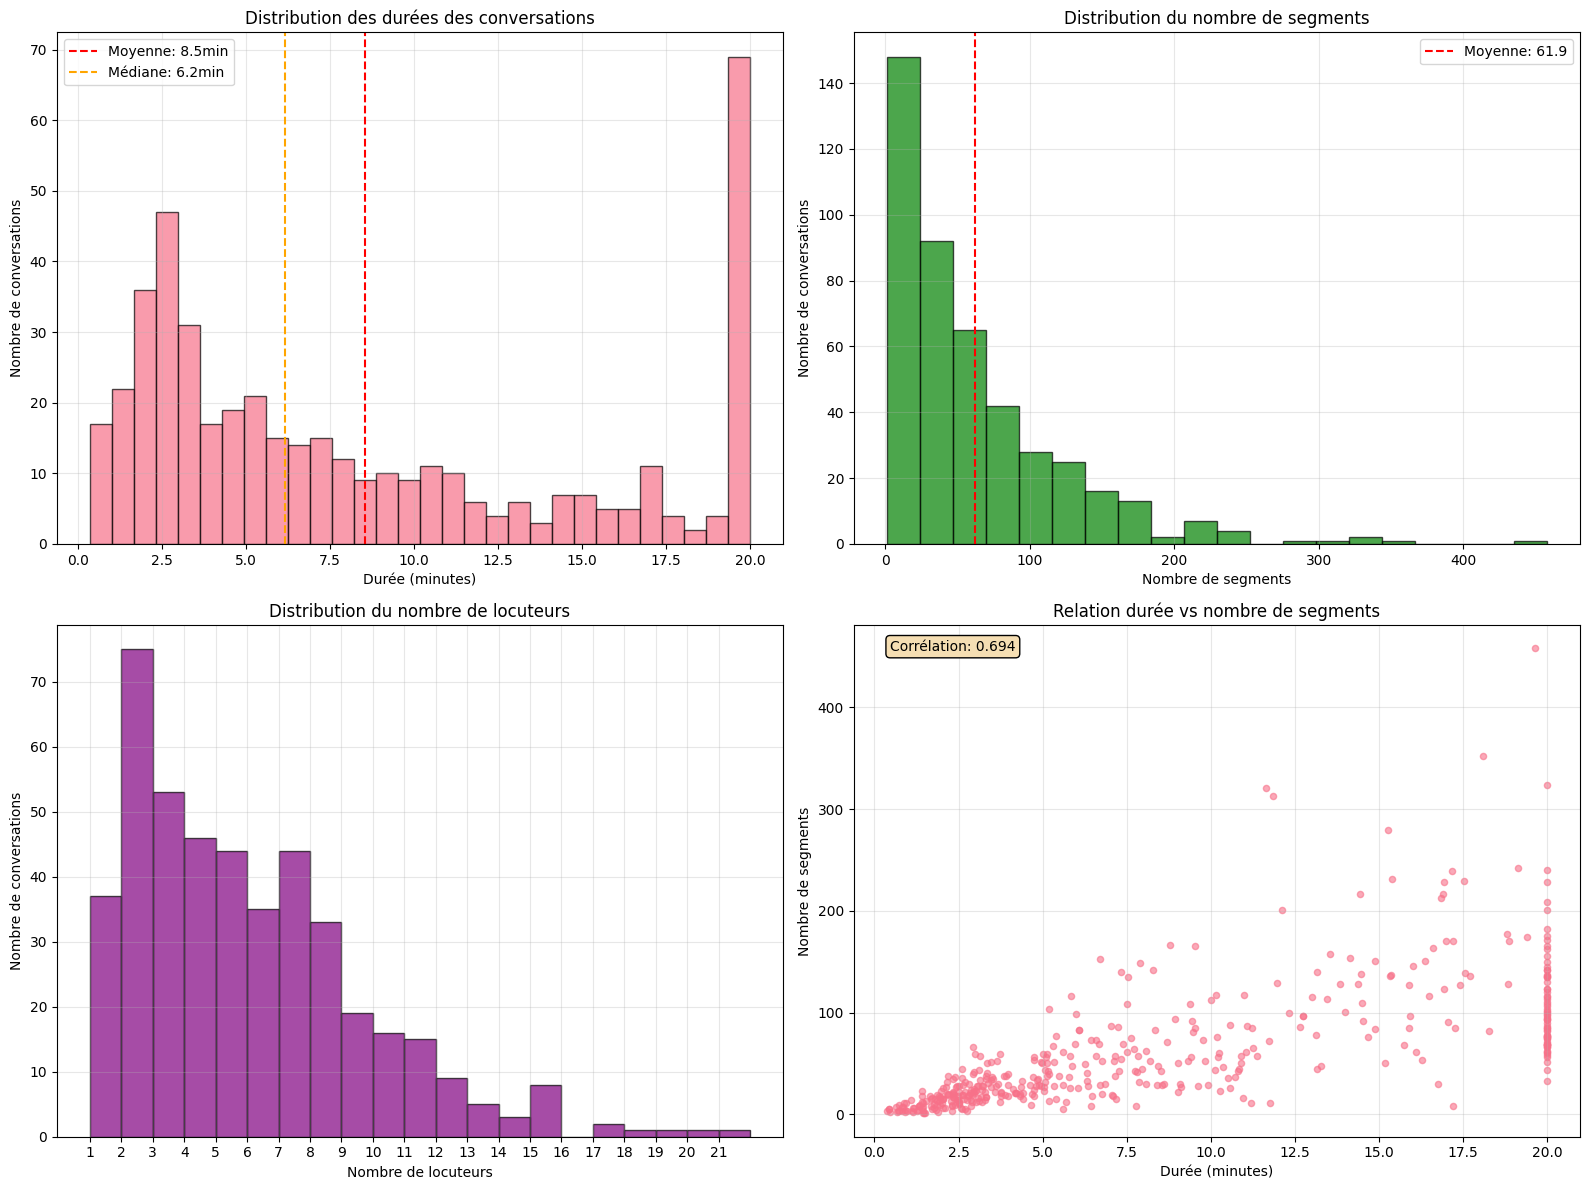


=== PERCENTILES DES DURÉES ===
P10: 108.09s (1.80min)
P25: 172.53s (2.88min)
P50: 370.40s (6.17min)
P75: 863.88s (14.40min)
P90: 1200.06s (20.00min)
P95: 1200.06s (20.00min)
P99: 1200.06s (20.00min)

=== RÉPARTITION PAR CATÉGORIES DE DURÉE ===
Conversations courtes (< 1min): 17 (3.8%)
Conversations moyennes (1-5min): 174 (38.8%)
Conversations longues (5-10min): 100 (22.3%)
Conversations très longues (> 10min): 157 (35.0%)


In [ ]:
# Analyse de la distribution du temps des conversations dans VoxConverse
print("=== DISTRIBUTION DU TEMPS DES CONVERSATIONS - VOXCONVERSE ===")

# Analyser tous les éléments du dataset
all_durations = []
all_segments_count = []
all_speakers_count = []

# Analyser le split 'dev'
print("Analyse du split 'dev'...")
for i, item in enumerate(ds['dev']):
    if i % 50 == 0:
        print(f"  Traitement élément {i+1}/{len(ds['dev'])}")
    
    # Calculer la durée totale de l'audio
    duration = len(item['audio']['array']) / item['audio']['sampling_rate']
    all_durations.append(duration)
    
    # Compter les segments
    num_segments = len(item['timestamps_start'])
    all_segments_count.append(num_segments)
    
    # Compter les locuteurs uniques
    unique_speakers = len(set(item['speakers']))
    all_speakers_count.append(unique_speakers)

# Analyser le split 'test'
print("Analyse du split 'test'...")
for i, item in enumerate(ds['test']):
    if i % 50 == 0:
        print(f"  Traitement élément {i+1}/{len(ds['test'])}")
    
    # Calculer la durée totale de l'audio
    duration = len(item['audio']['array']) / item['audio']['sampling_rate']
    all_durations.append(duration)
    
    # Compter les segments
    num_segments = len(item['timestamps_start'])
    all_segments_count.append(num_segments)
    
    # Compter les locuteurs uniques
    unique_speakers = len(set(item['speakers']))
    all_speakers_count.append(unique_speakers)

# Convertir en numpy arrays pour les calculs
all_durations = np.array(all_durations)
all_segments_count = np.array(all_segments_count)
all_speakers_count = np.array(all_speakers_count)

print(f"\nNombre total de conversations analysées: {len(all_durations)}")
print(f"  - Split dev: {len(ds['dev'])} conversations")
print(f"  - Split test: {len(ds['test'])} conversations")

# Statistiques générales
print(f"\n=== STATISTIQUES GÉNÉRALES ===")
print(f"Durée totale du dataset: {all_durations.sum()/3600:.2f} heures")
print(f"Durée moyenne par conversation: {all_durations.mean():.2f} secondes ({all_durations.mean()/60:.2f} minutes)")
print(f"Durée médiane: {np.median(all_durations):.2f} secondes")
print(f"Durée minimale: {all_durations.min():.2f} secondes")
print(f"Durée maximale: {all_durations.max():.2f} secondes")
print(f"Écart-type: {all_durations.std():.2f} secondes")

print(f"\nSegments de diarization:")
print(f"Nombre moyen de segments par conversation: {all_segments_count.mean():.1f}")
print(f"Nombre médian de segments: {np.median(all_segments_count):.0f}")
print(f"Min/Max segments: {all_segments_count.min()} / {all_segments_count.max()}")

print(f"\nNombre de locuteurs:")
print(f"Nombre moyen de locuteurs par conversation: {all_speakers_count.mean():.1f}")
print(f"Nombre médian de locuteurs: {np.median(all_speakers_count):.0f}")
print(f"Min/Max locuteurs: {all_speakers_count.min()} / {all_speakers_count.max()}")

# Créer les graphiques de distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Distribution des durées
axes[0, 0].hist(all_durations/60, bins=30, alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Durée (minutes)')
axes[0, 0].set_ylabel('Nombre de conversations')
axes[0, 0].set_title('Distribution des durées des conversations')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axvline(all_durations.mean()/60, color='red', linestyle='--', label=f'Moyenne: {all_durations.mean()/60:.1f}min')
axes[0, 0].axvline(np.median(all_durations)/60, color='orange', linestyle='--', label=f'Médiane: {np.median(all_durations)/60:.1f}min')
axes[0, 0].legend()

# Distribution des nombres de segments
axes[0, 1].hist(all_segments_count, bins=20, alpha=0.7, edgecolor='black', color='green')
axes[0, 1].set_xlabel('Nombre de segments')
axes[0, 1].set_ylabel('Nombre de conversations')
axes[0, 1].set_title('Distribution du nombre de segments')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axvline(all_segments_count.mean(), color='red', linestyle='--', label=f'Moyenne: {all_segments_count.mean():.1f}')
axes[0, 1].legend()

# Distribution des nombres de locuteurs
axes[1, 0].hist(all_speakers_count, bins=range(int(all_speakers_count.min()), int(all_speakers_count.max())+2), 
                alpha=0.7, edgecolor='black', color='purple')
axes[1, 0].set_xlabel('Nombre de locuteurs')
axes[1, 0].set_ylabel('Nombre de conversations')
axes[1, 0].set_title('Distribution du nombre de locuteurs')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xticks(range(int(all_speakers_count.min()), int(all_speakers_count.max())+1))

# Relation durée vs nombre de segments
axes[1, 1].scatter(all_durations/60, all_segments_count, alpha=0.6, s=20)
axes[1, 1].set_xlabel('Durée (minutes)')
axes[1, 1].set_ylabel('Nombre de segments')
axes[1, 1].set_title('Relation durée vs nombre de segments')
axes[1, 1].grid(True, alpha=0.3)

# Calculer la corrélation
correlation = np.corrcoef(all_durations, all_segments_count)[0, 1]
axes[1, 1].text(0.05, 0.95, f'Corrélation: {correlation:.3f}', 
                transform=axes[1, 1].transAxes, bbox=dict(boxstyle="round", facecolor='wheat'))

plt.tight_layout()
plt.show()

# Percentiles et quartiles
print(f"\n=== PERCENTILES DES DURÉES ===")
percentiles = [10, 25, 50, 75, 90, 95, 99]
for p in percentiles:
    duration_p = np.percentile(all_durations, p)
    print(f"P{p}: {duration_p:.2f}s ({duration_p/60:.2f}min)")

# Répartition par catégories de durée
print(f"\n=== RÉPARTITION PAR CATÉGORIES DE DURÉE ===")
short_conv = np.sum(all_durations < 60)  # < 1 minute
medium_conv = np.sum((all_durations >= 60) & (all_durations < 300))  # 1-5 minutes
long_conv = np.sum((all_durations >= 300) & (all_durations < 600))  # 5-10 minutes
very_long_conv = np.sum(all_durations >= 600)  # > 10 minutes

print(f"Conversations courtes (< 1min): {short_conv} ({short_conv/len(all_durations)*100:.1f}%)")
print(f"Conversations moyennes (1-5min): {medium_conv} ({medium_conv/len(all_durations)*100:.1f}%)")
print(f"Conversations longues (5-10min): {long_conv} ({long_conv/len(all_durations)*100:.1f}%)")
print(f"Conversations très longues (> 10min): {very_long_conv} ({very_long_conv/len(all_durations)*100:.1f}%)")

In [ ]:
# Analyse des CONVERSATIONS COMPLÈTES les plus courtes et les plus longues
print("=== ANALYSE DES CONVERSATIONS COMPLÈTES LES PLUS COURTES ET LES PLUS LONGUES ===")

# Collecter toutes les conversations avec leurs informations complètes
all_conversations = []

print("Collecte des informations sur toutes les conversations...")

# Analyser tous les splits
for split_name in ['dev', 'test']:
    print(f"  Analyse du split '{split_name}'...")
    split_data = ds[split_name]
    
    for item_idx, item in enumerate(split_data):
        if item_idx % 50 == 0:
            print(f"    Conversation {item_idx+1}/{len(split_data)}")
        
        # Calculer la durée totale de l'audio de la conversation
        audio_duration = len(item['audio']['array']) / item['audio']['sampling_rate']
        
        # Collecter les informations de la conversation
        conversation_info = {
            'split': split_name,
            'item_idx': item_idx,
            'duration': audio_duration,
            'num_segments': len(item['timestamps_start']),
            'num_speakers': len(set(item['speakers'])),
            'item': item  # Garder une référence à l'item complet pour l'audio
        }
        all_conversations.append(conversation_info)

print(f"\nNombre total de conversations collectées: {len(all_conversations)}")

# Trier par durée
all_conversations.sort(key=lambda x: x['duration'])

if len(all_conversations) > 0:
    # Conversations les plus courtes et les plus longues
    shortest_conversations = all_conversations[:5]
    longest_conversations = all_conversations[-5:]
    
    
    
    # Préparer les audios des conversations extrêmes
    print(f"\n=== PRÉPARATION DES AUDIOS DES CONVERSATIONS COMPLÈTES ===")
    
    # Conversation la plus courte
    shortest_conv = shortest_conversations[0]
    print(f"Conversation la plus courte: {shortest_conv['duration']:.2f}s ({shortest_conv['duration']/60:.2f}min)")
    print(f"Split: {shortest_conv['split']}, Index: {shortest_conv['item_idx']}")
    print(f"Segments: {shortest_conv['num_segments']}, Locuteurs: {shortest_conv['num_speakers']}")
    
    # Extraire l'audio complet de la conversation la plus courte
    shortest_audio = np.array(shortest_conv['item']['audio']['array'])
    shortest_sample_rate = shortest_conv['item']['audio']['sampling_rate']
    
    print(f"Audio de la conversation la plus courte préparé: {len(shortest_audio)/shortest_sample_rate:.2f}s")
    
    # Conversation la plus longue
    longest_conv = longest_conversations[-1]
    print(f"\nConversation la plus longue: {longest_conv['duration']:.2f}s ({longest_conv['duration']/60:.2f}min)")
    print(f"Split: {longest_conv['split']}, Index: {longest_conv['item_idx']}")
    print(f"Segments: {longest_conv['num_segments']}, Locuteurs: {longest_conv['num_speakers']}")
    
    # Extraire l'audio complet de la conversation la plus longue
    longest_audio = np.array(longest_conv['item']['audio']['array'])
    longest_sample_rate = longest_conv['item']['audio']['sampling_rate']
    
    print(f"Audio de la conversation la plus longue préparé: {len(longest_audio)/longest_sample_rate:.2f}s")
    
    # Afficher les timelines des conversations extrêmes
    print(f"\n=== TIMELINE DE LA CONVERSATION LA PLUS COURTE ===")
    shortest_item_info = analyze_voxconverse_item(shortest_conv['item'])
    if shortest_item_info['segments']:
        plot_voxconverse_timeline(shortest_item_info, title_suffix=f" - Conversation la plus courte ({shortest_conv['duration']:.1f}s)")
    
    print(f"\n=== TIMELINE DE LA CONVERSATION LA PLUS LONGUE")
    longest_item_info = analyze_voxconverse_item(longest_conv['item'])
    if longest_item_info['segments']:
        # Afficher seulement les premières 5 minutes pour la lisibilité
        plot_voxconverse_timeline(longest_item_info, 
                                title_suffix=f" - Conversation la plus longue ({longest_conv['duration']/60:.1f}min)")
    
    print(f"\n=== LECTEURS AUDIO DES CONVERSATIONS COMPLÈTES ===")
    
    # Lecteur pour la conversation la plus courte
    print("🎵 CONVERSATION LA PLUS COURTE (audio complet)")
    print(f"   Durée: {shortest_conv['duration']:.2f}s ({shortest_conv['duration']/60:.2f}min)")
    print(f"   Segments: {shortest_conv['num_segments']}, Locuteurs: {shortest_conv['num_speakers']}")
    shortest_audio_widget = ipd.Audio(shortest_audio, rate=shortest_sample_rate, autoplay=False)
    display(shortest_audio_widget)
    
    # Lecteur pour la conversation la plus longue
    print(f"\n🎵 CONVERSATION LA PLUS LONGUE (audio complet)")
    print(f"   Durée: {longest_conv['duration']:.2f}s ({longest_conv['duration']/60:.2f}min)")
    print(f"   Segments: {longest_conv['num_segments']}, Locuteurs: {longest_conv['num_speakers']}")
    longest_audio_widget = ipd.Audio(longest_audio, rate=longest_sample_rate, autoplay=False)
    display(longest_audio_widget)
    
    # Ajouter quelques conversations de durées moyennes pour comparaison
    print(f"\n🎵 CONVERSATIONS DE RÉFÉRENCE (durées moyennes)")
    middle_idx = len(all_conversations) // 2
    
    
    # Afficher un résumé des audios disponibles
    print(f"\n📊 RÉSUMÉ DES CONVERSATIONS DISPONIBLES:")
    print(f"   • Conversation la plus courte: {shortest_conv['duration']:.2f}s ({shortest_conv['duration']/60:.2f}min)")
    print(f"   • Conversation la plus longue: {longest_conv['duration']:.2f}s ({longest_conv['duration']/60:.2f}min)")
   
    
else:
    print("Aucune conversation trouvée dans le dataset.")

=== ANALYSE DES CONVERSATIONS COMPLÈTES LES PLUS COURTES ET LES PLUS LONGUES ===
Collecte des informations sur toutes les conversations...
  Analyse du split 'dev'...
    Conversation 1/216
    Conversation 51/216
    Conversation 51/216
    Conversation 101/216
    Conversation 101/216


    Conversation 151/216
    Conversation 201/216
    Conversation 201/216
  Analyse du split 'test'...
    Conversation 1/232
  Analyse du split 'test'...
    Conversation 1/232
    Conversation 51/232
    Conversation 51/232
    Conversation 101/232
    Conversation 101/232
    Conversation 151/232
    Conversation 151/232


KeyboardInterrupt: 